# Model comparison (micro level)

Density, Time of Presence, Stop duration. Real tracks vs simulated (Unity CSV).

**Input:** DXF with floor plan, folder with real-trajectory CSVs, folder with Unity simulation CSVs.


In [1]:
import sys
from pathlib import Path

for d in [Path.cwd(), Path.cwd() / "model_search"]:
    if (d / "density.py").exists() and str(d) not in sys.path:
        sys.path.insert(0, str(d))
        break

PATH_DXF = r"C:\Users\malko\Desktop\Diploma\Term\bird-dataset-main\model_search\Floor_0.dxf"
PATH_TRAJECTORIES_CSV = "C://Users/malko/Desktop/Diploma/Term/bird-dataset-main/bird-dataset-main/data/normalized_trajectories"
CELL_SIZE_M = 1.0
PATH_UNITY_DXF = r"C:\Users\malko\Desktop\Diploma\Term\bird-dataset-main\model_search\unity_plan_and_tracks.dxf"
PATH_SIMULATION_CSV = r"C:\Users\malko\Nancy_floor0\Assets\StreamingAssets\unity_tracks_bird"


In [2]:
%pip install -q ezdxf pandas matplotlib numpy


Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.0 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


## Micro level

Movement metrics per zone: density, time of presence, distribution of stop durations.

**Start of section:** floor plan + tracks + grid (real and simulated).

### Density maps

Visitor density per unit area. Grid 1×1 m (parameter `CELL_SIZE_M`).

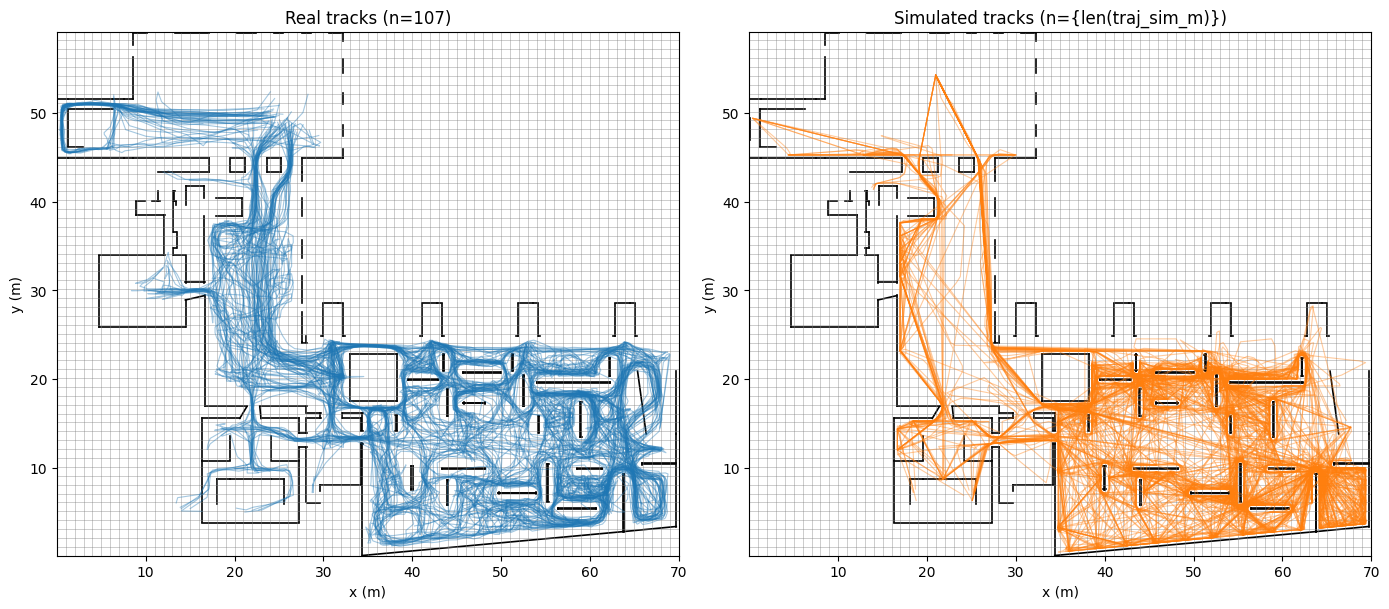

In [3]:
# Intro: floor plan + tracks + grid (real and simulated)
import matplotlib.pyplot as plt
import numpy as np

from density import load_floor0_trajectories, SCALE_FACTOR, compute_density_analysis
from plot_density_grids import load_floor_plan_segments, plot_plan_with_grid, plot_plan_with_grid_and_tracks

path_dxf = Path(PATH_DXF) if isinstance(PATH_DXF, str) else PATH_DXF
segments = load_floor_plan_segments(path_dxf, "Floor_plan")

# Grid and BIRD tracks
d_real = compute_density_analysis(PATH_TRAJECTORIES_CSV, cell_size_m=CELL_SIZE_M)
xe, ye = d_real["x_edges"], d_real["y_edges"]
base = Path("model_search") if (Path.cwd() / "model_search").exists() else Path(".")
grid_json = base / "density_floor0.json"
if not grid_json.exists():
    import json
    json.dump({"x_edges_m": [round(float(x), 4) for x in xe], "y_edges_m": [round(float(y), 4) for y in ye]}, open(grid_json, "w", encoding="utf-8"), indent=2)
traj_bird, _, _, _ = load_floor0_trajectories(PATH_TRAJECTORIES_CSV)
# Split tracks on large distance or time jump (same as model_search_macro)
MAX_JUMP_M = 5.0
MAX_GAP_SEC = 300.0

def split_trajectory_by_gaps(df, scale_factor, max_jump_m, max_gap_sec):
    """Split trajectory into segments when dist > max_jump_m (m) or time_diff > max_gap_sec (s)."""
    x_m = df["x"].astype(float).values * scale_factor
    y_m = df["y"].astype(float).values * scale_factor
    ts = df["timestamp"].astype(float).values
    if len(x_m) < 2:
        return [[(float(x_m[0]), float(y_m[0]))]] if len(x_m) == 1 else []
    dist = np.sqrt(np.diff(x_m) ** 2 + np.diff(y_m) ** 2)
    time_diff = np.diff(ts)
    breaks = np.where((dist > max_jump_m) | (time_diff > max_gap_sec))[0] + 1
    breaks = np.concatenate([[0], breaks, [len(x_m)]])
    segments = []
    for j in range(len(breaks) - 1):
        start, end = int(breaks[j]), int(breaks[j + 1])
        if end - start >= 2:
            segments.append([(float(x_m[k]), float(y_m[k])) for k in range(start, end)])
    return segments

traj_real_m = []
for df in traj_bird:
    traj_real_m.extend(split_trajectory_by_gaps(df, SCALE_FACTOR, MAX_JUMP_M, MAX_GAP_SEC))

# Simulated tracks and plan from unity_plan_and_tracks.dxf (Outline/PLAN_FLOOR -> meters)
traj_sim_m = None
segments_sim = []
path_floor_dxf = Path(PATH_DXF) if isinstance(PATH_DXF, str) else Path(PATH_DXF)
path_unity_dxf = Path(PATH_UNITY_DXF) if isinstance(PATH_UNITY_DXF, str) else Path(PATH_UNITY_DXF)
if path_unity_dxf.exists():
    try:
        from room_popularity import load_simulated_trajectories_from_unity_dxf, load_unity_plan_segments_in_floor0_meters
        traj_sim_raw = load_simulated_trajectories_from_unity_dxf(path_floor_dxf, path_unity_dxf, layer_reference_bird="Outline", layer_tracks_unity="TRACKS")
        traj_sim_m = [[(x * SCALE_FACTOR, y * SCALE_FACTOR) for (x, y) in tr] for tr in traj_sim_raw]
        segments_sim = load_unity_plan_segments_in_floor0_meters(path_floor_dxf, path_unity_dxf, scale_factor=SCALE_FACTOR)
    except Exception as e:
        print(f"[Simulation] Failed to load tracks/plan from unity DXF: {e}")
        traj_sim_m = None
        segments_sim = []
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_plan_with_grid_and_tracks(axes[0], segments, xe, ye, traj_real_m, f"Real tracks (n={len(traj_real_m)})", track_color="tab:blue")
if traj_sim_m is not None:
    plot_plan_with_grid_and_tracks(
        axes[1], segments, xe, ye, traj_sim_m,
        f"Simulated tracks (n={{len(traj_sim_m)}})",
        track_color="tab:orange",
    )
else:
    plot_plan_with_grid(xe, ye, segments, "Simulated tracks — no data", axes[1])
plt.tight_layout()
plt.show()

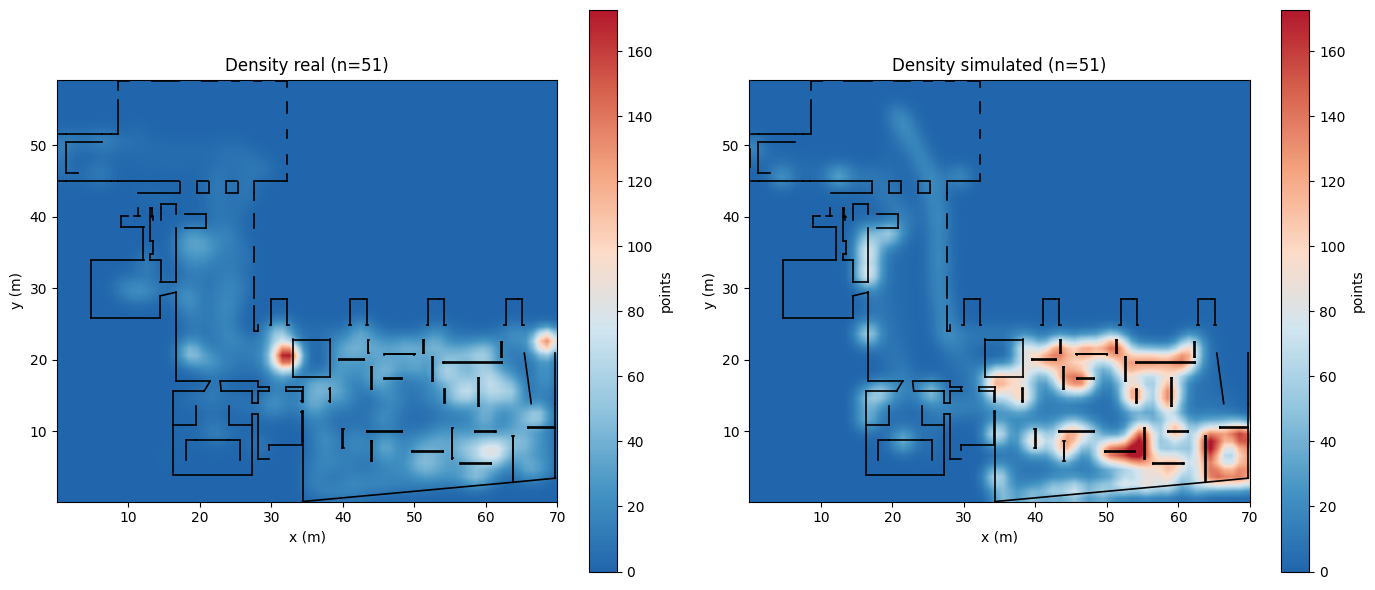

In [4]:
# Density: real and simulated
import json
import matplotlib.pyplot as plt
import numpy as np

# BIRD density
from density import compute_density_analysis as density_bird_analysis
d_real = density_bird_analysis(PATH_TRAJECTORIES_CSV, cell_size_m=CELL_SIZE_M)

# Save grid for density_Unity (if density_floor0.json not created yet)
base = Path("model_search") if (Path.cwd() / "model_search").exists() else Path(".")
grid_json = base / "density_floor0.json"
if not grid_json.exists():
    json.dump(
        {"x_edges_m": [round(float(x), 4) for x in d_real["x_edges"]], "y_edges_m": [round(float(y), 4) for y in d_real["y_edges"]]},
        open(grid_json, "w", encoding="utf-8"),
        indent=2,
    )

# Unity density (on BIRD grid)
# First try CSV with two-stage scaling (stops, ToP); otherwise use tracks from DXF
d_sim = None
if 'PATH_SIMULATION_CSV' in dir() and PATH_SIMULATION_CSV and 'path_floor_dxf' in dir() and 'path_unity_dxf' in dir() and path_unity_dxf.exists():
    try:
        from room_popularity import load_simulated_trajectories_from_csv_in_meters
        from density import compute_time_of_presence
        traj_sim_csv = load_simulated_trajectories_from_csv_in_meters(path_floor_dxf, path_unity_dxf, PATH_SIMULATION_CSV, SCALE_FACTOR)
        xe, ye = d_real["x_edges"], d_real["y_edges"]
        nx, ny = len(xe) - 1, len(ye) - 1
        all_x = np.concatenate([df["x"].values for df in traj_sim_csv])
        all_y = np.concatenate([df["y"].values for df in traj_sim_csv])
        hm, _, _ = np.histogram2d(all_x, all_y, bins=[xe, ye])
        hm = hm.T
        # ToP uses same function as real: real has one scale step (raw→m), simulated is already in meters → scale_factor=1.0
        top_matrix, stop_durations = compute_time_of_presence(traj_sim_csv, xe, ye, nx, ny, scale_factor=1.0)
        stop_duration_stats = {}
        if stop_durations:
            arr = np.array(stop_durations)
            long_stop_threshold_sec = 30.0
            stop_duration_stats = {"n_stops": len(stop_durations), "mean_sec": round(float(np.mean(arr)), 2), "median_sec": round(float(np.median(arr)), 2), "p75_sec": round(float(np.percentile(arr, 75)), 2), "p90_sec": round(float(np.percentile(arr, 90)), 2), "long_stop_threshold_sec": long_stop_threshold_sec, "proportion_long_stops": round(float(np.mean(arr >= long_stop_threshold_sec)), 4)}
        d_sim = {"heatmap": hm, "top_matrix": top_matrix, "x_edges": xe, "y_edges": ye, "n_trajectories": len(traj_sim_csv), "stop_duration_stats": stop_duration_stats}
    except Exception as e:
        print(f"[Simulation CSV] Failed to load: {e}")
if d_sim is None and 'traj_sim_m' in dir() and traj_sim_m and len(traj_sim_m) > 0:
    import numpy as np
    all_x = np.concatenate([[p[0] for p in tr] for tr in traj_sim_m])
    all_y = np.concatenate([[p[1] for p in tr] for tr in traj_sim_m])
    xe, ye = d_real["x_edges"], d_real["y_edges"]
    hm, _, _ = np.histogram2d(all_x, all_y, bins=[xe, ye])
    hm = hm.T
    d_sim = {"heatmap": hm, "top_matrix": np.zeros_like(hm), "x_edges": xe, "y_edges": ye, "n_trajectories": len(traj_sim_m)}

# Load floor plan for overlay
from plot_density_grids import load_floor_plan_segments, plot_heatmap_on_plan
path_dxf = Path(PATH_DXF) if isinstance(PATH_DXF, str) else PATH_DXF
segments = load_floor_plan_segments(path_dxf, "Floor_plan")
xe, ye = d_real["x_edges"], d_real["y_edges"]

# Density: raw counts (points per cell), no normalization — shared scale
hm_real = d_real["heatmap"]
hm_sim = d_sim["heatmap"] if d_sim is not None else None
vals_d = np.concatenate([hm_real[hm_real > 0].ravel(), hm_sim[hm_sim > 0].ravel() if hm_sim is not None else []])
vmax_d = float(np.percentile(vals_d, 95)) if len(vals_d) > 0 else max(hm_real.max(), hm_sim.max() if hm_sim is not None else 0)
vmin_d, vmax_d = 0, vmax_d

from scipy.ndimage import gaussian_filter
sigma_d = 1.2
hm_real_smooth = gaussian_filter(hm_real.astype(float), sigma=sigma_d, mode="constant", cval=0)
hm_sim_smooth = gaussian_filter(hm_sim.astype(float), sigma=sigma_d, mode="constant", cval=0) if hm_sim is not None else None

import matplotlib.colors as mcolors
# Colormap: dark blue (33,102,172) to dark red (178,24,43)
density_colors = [
    (0, (33/255, 102/255, 172/255)),
    (0.14, (67/255, 147/255, 195/255)),
    (0.29, (146/255, 197/255, 222/255)),
    (0.43, (209/255, 229/255, 240/255)),
    (0.57, (253/255, 219/255, 199/255)),
    (0.71, (244/255, 165/255, 130/255)),
    (0.86, (214/255, 96/255, 77/255)),
    (1, (178/255, 24/255, 43/255)),
]
density_cmap = mcolors.LinearSegmentedColormap.from_list("density_cool_warm", density_colors, N=256)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_heatmap_on_plan(axes[0], hm_real_smooth, xe, ye, segments, f"Density real (n={d_real['n_trajectories']})", label="points", vmin=vmin_d, vmax=vmax_d, cmap=density_cmap, draw_grid=False, interpolation="bilinear")
if d_sim is not None:
    plot_heatmap_on_plan(axes[1], hm_sim_smooth, xe, ye, segments, f"Density simulated (n={d_sim['n_trajectories']})", label="points", vmin=vmin_d, vmax=vmax_d, cmap=density_cmap, draw_grid=False, interpolation="bilinear")
else:
    axes[1].set_title("Density simulated — no data")
plt.tight_layout()
plt.show()

### Comparison of density maps

Metrics and difference map for the density maps above (real vs simulated).

Correlation:
  Pearson r = 0.5507, Spearman ρ = 0.7874 (p = 0.0000)
Errors:
  MAE = 16.2466, RMSE = 30.7479, NMAE = 1.4676


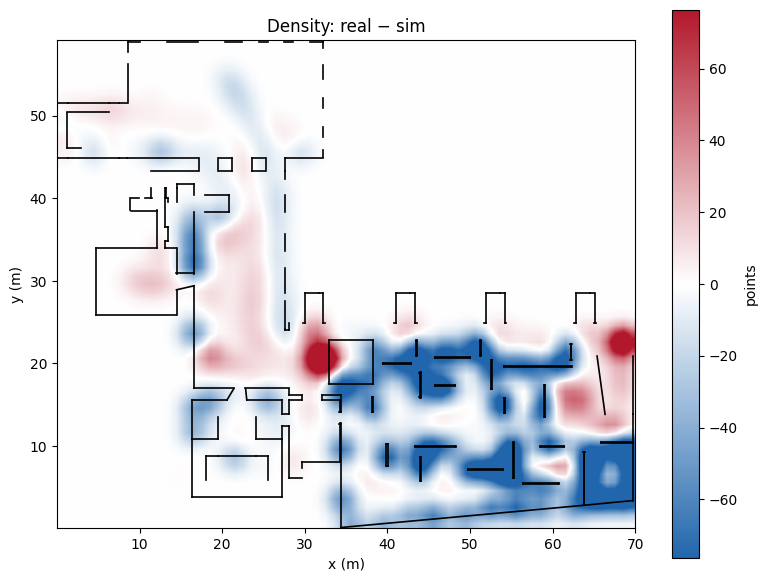

In [5]:
# Comparison of density maps (run after Density cells above)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import pearsonr, spearmanr
try:
    from skimage.metrics import structural_similarity as ssim
    HAS_SSIM = True
except ImportError:
    HAS_SSIM = False

def _compare_maps(real, sim, name):
    r_flat, s_flat = np.asarray(real).ravel(), np.asarray(sim).ravel()
    mask = (r_flat > 0) | (s_flat > 0)
    if mask.sum() < 2:
        print(f"{name}: too few cells"); return
    r, p = pearsonr(r_flat[mask], s_flat[mask])
    r_spear, _ = spearmanr(r_flat[mask], s_flat[mask])
    print(f"  Pearson r = {r:.4f}, Spearman ρ = {r_spear:.4f} (p = {p:.4f})")

def _map_errors(real, sim, name):
    real, sim = np.asarray(real).astype(float), np.asarray(sim).astype(float)
    mask = (real > 0) | (sim > 0)
    if mask.sum() == 0:
        print(f"{name}: no cells"); return
    r, s = real[mask], sim[mask]
    mae = float(np.mean(np.abs(r - s)))
    rmse = float(np.sqrt(np.mean((r - s) ** 2)))
    nmae = mae / (float(np.mean(r)) + 1e-9)
    print(f"  MAE = {mae:.4f}, RMSE = {rmse:.4f}, NMAE = {nmae:.4f}")

if d_sim is None or hm_sim_smooth is None:
    print("No simulated density — skip comparison.")
else:
    print("Correlation:"); _compare_maps(hm_real_smooth, hm_sim_smooth, "Density")
    print("Errors:"); _map_errors(hm_real_smooth, hm_sim_smooth, "Density")
    if HAS_SSIM:
        dr = max(hm_real_smooth.max(), hm_sim_smooth.max()) - min(hm_real_smooth.min(), hm_sim_smooth.min()) or 1.0
        print(f"  SSIM = {ssim(hm_real_smooth, hm_sim_smooth, data_range=dr):.4f}")
    from plot_density_grids import plot_heatmap_on_plan
    diff_d = hm_real_smooth - hm_sim_smooth
    v_abs = np.percentile(np.abs(diff_d[diff_d != 0]), 95) if np.any(diff_d != 0) else 1e-9
    v_abs = max(float(v_abs), 1e-9)
    cmap_div = mcolors.LinearSegmentedColormap.from_list("div", ["#2166ac", "white", "#b2182b"], N=256)
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_heatmap_on_plan(ax, diff_d, xe, ye, segments, "Density: real − sim", label="points", vmin=-v_abs, vmax=v_abs, cmap=cmap_div, draw_grid=False, interpolation="bilinear")
    plt.tight_layout()
    plt.show()

### Global totals (Density)

Total density (points) over the floor: real vs simulated.

In [6]:
# Global totals — Density (run after Density comparison above)
density_real = int(d_real["heatmap"].sum())
print("Real:    total density (points) =", density_real)
if d_sim is not None:
    density_sim = int(d_sim["heatmap"].sum())
    print("Simulated: total density (points) =", density_sim)
    print("Ratio sim/real =", round(density_sim / max(density_real, 1), 4))
else:
    print("Simulated: no data")

Real:    total density (points) = 31733
Simulated: total density (points) = 62526
Ratio sim/real = 1.9704


### Time of Presence (ToP)

Time of presence = total time (s) per cell over all agents.

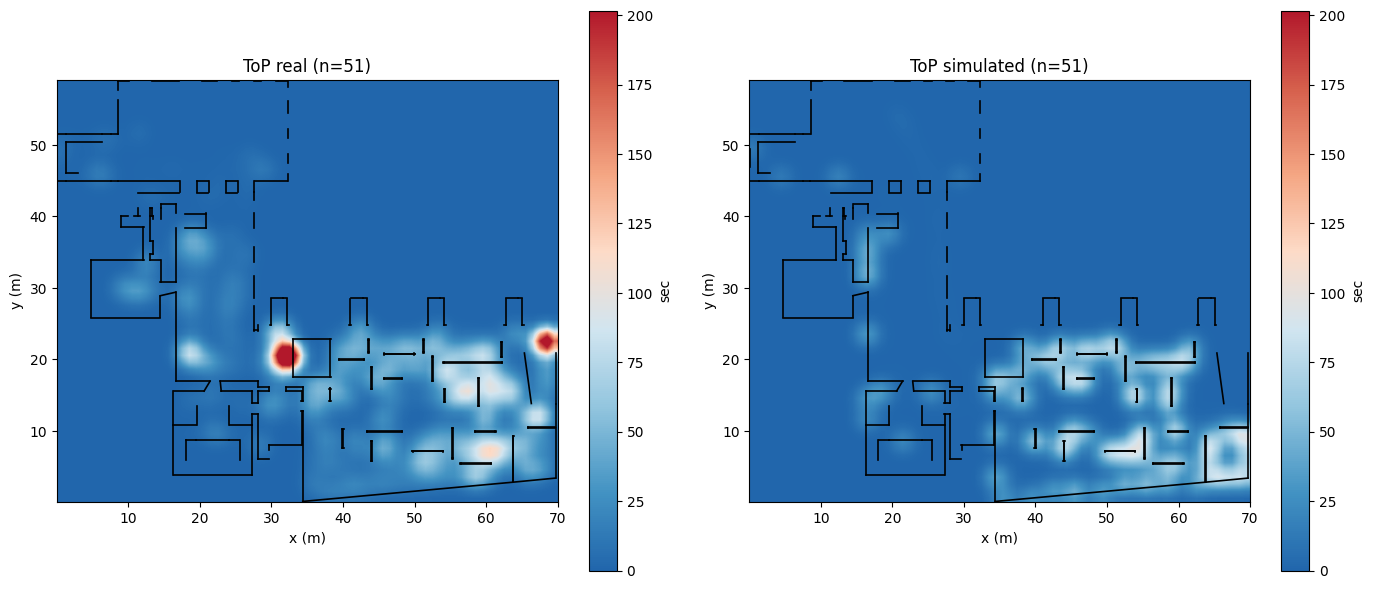

In [7]:
# Time of Presence: same colormap as Density; smoothing on data and when plotting
import matplotlib.colors as mcolors
from scipy.ndimage import gaussian_filter
top_real, top_sim = d_real["top_matrix"], d_sim["top_matrix"] if d_sim is not None else None
sigma = 1.2
top_real_smooth = gaussian_filter(top_real.astype(float), sigma=sigma, mode="constant", cval=0)
top_sim_smooth = gaussian_filter(top_sim.astype(float), sigma=sigma, mode="constant", cval=0) if top_sim is not None else None
vals_t = np.concatenate([top_real[top_real > 0].ravel(), top_sim[top_sim > 0].ravel() if top_sim is not None else []])
vmax_t = float(np.percentile(vals_t, 95)) if len(vals_t) > 0 else max(top_real.max(), top_sim.max() if top_sim is not None else 0)
vmin_t, vmax_t = 0, vmax_t

density_colors_top = [(0, (33/255, 102/255, 172/255)), (0.14, (67/255, 147/255, 195/255)), (0.29, (146/255, 197/255, 222/255)), (0.43, (209/255, 229/255, 240/255)), (0.57, (253/255, 219/255, 199/255)), (0.71, (244/255, 165/255, 130/255)), (0.86, (214/255, 96/255, 77/255)), (1, (178/255, 24/255, 43/255))]
top_cmap = mcolors.LinearSegmentedColormap.from_list("top_cool_warm", density_colors_top, N=256)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
plot_heatmap_on_plan(axes[0], top_real_smooth, xe, ye, segments, f"ToP real (n={d_real['n_trajectories']})", label="sec", vmin=vmin_t, vmax=vmax_t, cmap=top_cmap, draw_grid=False, interpolation="bilinear")
if d_sim is not None:
    plot_heatmap_on_plan(axes[1], top_sim_smooth, xe, ye, segments, f"ToP simulated (n={d_sim['n_trajectories']})", label="sec", vmin=vmin_t, vmax=vmax_t, cmap=top_cmap, draw_grid=False, interpolation="bilinear")
else:
    axes[1].set_title("ToP simulated — no data")
plt.tight_layout()
plt.show()

### Comparison of ToP maps

Metrics and difference map for the Time of Presence maps above (real vs simulated).

Correlation:
  Pearson r = 0.4214, Spearman ρ = 0.7351 (p = 0.0000)
Errors:
  MAE = 10.7615, RMSE = 24.6325, NMAE = 0.7614


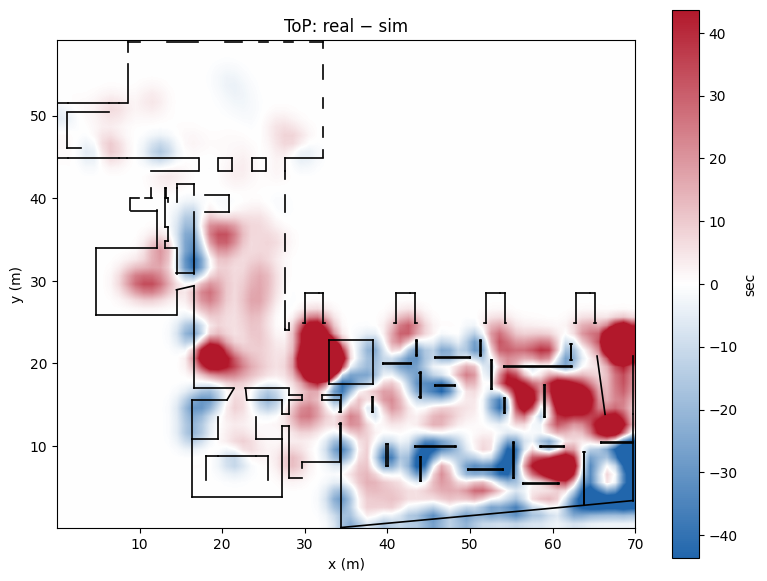

In [8]:
# Comparison of ToP maps (run after ToP cells above)
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.colors as mcolors
from scipy.stats import pearsonr, spearmanr
try:
    from skimage.metrics import structural_similarity as ssim
    HAS_SSIM = True
except ImportError:
    HAS_SSIM = False

def _compare_maps(real, sim, name):
    r_flat, s_flat = np.asarray(real).ravel(), np.asarray(sim).ravel()
    mask = (r_flat > 0) | (s_flat > 0)
    if mask.sum() < 2:
        print(f"{name}: too few cells"); return
    r, p = pearsonr(r_flat[mask], s_flat[mask])
    r_spear, _ = spearmanr(r_flat[mask], s_flat[mask])
    print(f"  Pearson r = {r:.4f}, Spearman ρ = {r_spear:.4f} (p = {p:.4f})")

def _map_errors(real, sim, name):
    real, sim = np.asarray(real).astype(float), np.asarray(sim).astype(float)
    mask = (real > 0) | (sim > 0)
    if mask.sum() == 0:
        print(f"{name}: no cells"); return
    r, s = real[mask], sim[mask]
    mae = float(np.mean(np.abs(r - s)))
    rmse = float(np.sqrt(np.mean((r - s) ** 2)))
    nmae = mae / (float(np.mean(r)) + 1e-9)
    print(f"  MAE = {mae:.4f}, RMSE = {rmse:.4f}, NMAE = {nmae:.4f}")

if d_sim is None or top_sim_smooth is None:
    print("No simulated ToP — skip comparison.")
else:
    print("Correlation:"); _compare_maps(top_real_smooth, top_sim_smooth, "ToP")
    print("Errors:"); _map_errors(top_real_smooth, top_sim_smooth, "ToP (sec)")
    if HAS_SSIM:
        dr = max(top_real_smooth.max(), top_sim_smooth.max()) - min(top_real_smooth.min(), top_sim_smooth.min()) or 1.0
        print(f"  SSIM = {ssim(top_real_smooth, top_sim_smooth, data_range=dr):.4f}")
    from plot_density_grids import plot_heatmap_on_plan
    diff_t = top_real_smooth - top_sim_smooth
    v_abs = np.percentile(np.abs(diff_t[diff_t != 0]), 95) if np.any(diff_t != 0) else 1e-9
    v_abs = max(float(v_abs), 1e-9)
    cmap_div = mcolors.LinearSegmentedColormap.from_list("div", ["#2166ac", "white", "#b2182b"], N=256)
    fig, ax = plt.subplots(figsize=(8, 6))
    plot_heatmap_on_plan(ax, diff_t, xe, ye, segments, "ToP: real − sim", label="sec", vmin=-v_abs, vmax=v_abs, cmap=cmap_div, draw_grid=False, interpolation="bilinear")
    plt.tight_layout()
    plt.show()

### Global totals (ToP)

Total Time of Presence (seconds) over the floor: real vs simulated.

In [9]:
# Global totals — ToP (run after ToP comparison above)
top_real_sec = float(d_real["top_matrix"].sum())
print("Real:    total ToP =", round(top_real_sec, 1), "s", f"({top_real_sec/60:.1f} min)")
if d_sim is not None:
    top_sim_sec = float(d_sim["top_matrix"].sum())
    print("Simulated: total ToP =", round(top_sim_sec, 1), "s", f"({top_sim_sec/60:.1f} min)")
    print("Ratio sim/real =", round(top_sim_sec / max(top_real_sec, 1e-9), 4))
else:
    print("Simulated: no data")

Real:    total ToP = 39134.0 s (652.2 min)
Simulated: total ToP = 30171.0 s (502.9 min)
Ratio sim/real = 0.771


*(Global totals: Density above after density comparison; ToP above after ToP comparison.)*

In [10]:
# See "Global totals (Density)" and "Global totals (ToP)" in the sections above.

*(Comparison of density maps is above, after Density maps; comparison of ToP maps is above, after ToP maps.)*

In [11]:
# Comparisons are in the sections above (after Density maps and after ToP maps).

### Stop duration distribution

Stop duration stats (run of 2+ points in same cell): mean, median, 75th/90th percentiles, proportion of long stops.

In [12]:
# Stop duration: real vs simulated
def print_stop_stats(name, stats):
    if not stats:
        print(f"{name}: no stops")
        return
    print(f"{name}:")
    print(f"  n_stops: {stats.get('n_stops', '—')}")
    print(f"  mean: {stats.get('mean_sec', '-')} s, median: {stats.get('median_sec', '-')} s")
    print(f"  75th: {stats.get('p75_sec', '-')} s, 90th: {stats.get('p90_sec', '-')} s")
    thr = stats.get("long_stop_threshold_sec", 30)
    prop = stats.get("proportion_long_stops", 0)
    print(f"  proportion of long stops (>{thr} s): {prop:.2%}")

print_stop_stats("Real", d_real.get("stop_duration_stats"))
if d_sim is not None:
    print_stop_stats("Simulated", d_sim.get("stop_duration_stats"))

# Comparison: real vs simulated Stop duration
s_real = d_real.get("stop_duration_stats") or {}
s_sim = d_sim.get("stop_duration_stats") if d_sim else None
if s_sim and s_real:
    m_r, m_s = s_real.get("mean_sec"), s_sim.get("mean_sec")
    med_r, med_s = s_real.get("median_sec"), s_sim.get("median_sec")
    p_r, p_s = s_real.get("proportion_long_stops", 0), s_sim.get("proportion_long_stops", 0)
    print("Comparison (real vs simulated):")
    if m_r is not None and m_s is not None:
        print(f"  Mean stop duration: real {m_r} s, sim {m_s} s, diff = {m_r - m_s:.2f} s")
    if med_r is not None and med_s is not None:
        print(f"  Median: real {med_r} s, sim {med_s} s, diff = {med_r - med_s:.2f} s")
    print(f"  Proportion long stops: real {p_r:.2%}, sim {p_s:.2%}, diff = {p_r - p_s:.2%}")
else:
    if not s_real:
        print("Comparison: no real stop stats.")
    elif not s_sim:
        print("Comparison: no simulated data.")

Real:
  n_stops: 4380
  mean: 8.93 s, median: 4.0 s
  75th: 10.0 s, 90th: 18.0 s
  proportion of long stops (>30.0 s): 4.61%
Simulated:
  n_stops: 6206
  mean: 4.86 s, median: 0.61 s
  75th: 8.55 s, 90th: 16.7 s
  proportion of long stops (>30.0 s): 0.50%
Comparison (real vs simulated):
  Mean stop duration: real 8.93 s, sim 4.86 s, diff = 4.07 s
  Median: real 4.0 s, sim 0.61 s, diff = 3.39 s
  Proportion long stops: real 4.61%, sim 0.50%, diff = 4.11%


### Global summary

Summary of real vs simulated comparison for density, ToP, and Stop duration — based on the metrics computed above.

In [13]:
# Global summary from current analysis (run after all cells above)
import numpy as np
from IPython.display import display, Markdown
from scipy.stats import pearsonr, spearmanr

def _corr_errors(real, sim):
    r_flat = np.asarray(real).ravel().astype(float)
    s_flat = np.asarray(sim).ravel().astype(float)
    mask = (r_flat > 0) | (s_flat > 0)
    if mask.sum() < 2:
        return None
    r_pear, _ = pearsonr(r_flat[mask], s_flat[mask])
    r_spear, _ = spearmanr(r_flat[mask], s_flat[mask])
    rr, ss = r_flat[mask], s_flat[mask]
    mae = float(np.mean(np.abs(rr - ss)))
    nmae = mae / (float(np.mean(rr)) + 1e-9)
    return {"pearson": r_pear, "spearman": r_spear, "mae": mae, "nmae": nmae}

def _interpret_corr(spear):
    if spear >= 0.7: return "strong"
    if spear >= 0.4: return "moderate"
    if spear >= 0.2: return "weak"
    return "very weak / absent"

def _interpret_ratio(ratio):
    if ratio < 0.8: return "simulation clearly underestimates"
    if ratio < 1.0: return "simulation slightly underestimates"
    if ratio <= 1.2: return "simulation is close to reality"
    if ratio <= 1.5: return "simulation slightly overestimates"
    return "simulation clearly overestimates"

lines = ["## Global summary: real vs simulated\n"]

if d_sim is None or hm_sim_smooth is None:
    lines.append("Simulated data not loaded — comparison not possible.")
else:
    # Density
    d_met = _corr_errors(hm_real_smooth, hm_sim_smooth)
    d_tot_r = int(d_real["heatmap"].sum())
    d_tot_s = int(d_sim["heatmap"].sum())
    d_ratio = d_tot_s / max(d_tot_r, 1)
    lines.append("### Density")
    if d_met:
        lines.append(f"- **Correlation:** Pearson r = {d_met['pearson']:.3f}, Spearman ρ = {d_met['spearman']:.3f} — **{_interpret_corr(d_met['spearman'])}** agreement.")
        lines.append(f"- **Errors:** MAE = {d_met['mae']:.2f}, NMAE = {d_met['nmae']:.2f} — {'substantial differences in magnitude.' if d_met['nmae'] > 1 else 'moderate differences.'}")
    lines.append(f"- **Global total:** density sum real = {d_tot_r}, sim = {d_tot_s}, ratio sim/real = {d_ratio:.3f} — **{_interpret_ratio(d_ratio)}** overall visits.")
    lines.append("")

    # ToP
    t_met = _corr_errors(top_real_smooth, top_sim_smooth)
    t_tot_r = float(d_real["top_matrix"].sum())
    t_tot_s = float(d_sim["top_matrix"].sum())
    t_ratio = t_tot_s / max(t_tot_r, 1e-9)
    lines.append("### Time of Presence (ToP)")
    if t_met:
        lines.append(f"- **Correlation:** Pearson r = {t_met['pearson']:.3f}, Spearman ρ = {t_met['spearman']:.3f} — **{_interpret_corr(t_met['spearman'])}** agreement.")
        lines.append(f"- **Errors:** MAE = {t_met['mae']:.2f} s, NMAE = {t_met['nmae']:.2f} — {'substantial differences.' if t_met['nmae'] > 1 else 'moderate differences.'}")
    lines.append(f"- **Global total:** ToP sum real = {t_tot_r:.0f} s ({t_tot_r/60:.1f} min), sim = {t_tot_s:.0f} s ({t_tot_s/60:.1f} min), ratio sim/real = {t_ratio:.3f} — **{_interpret_ratio(t_ratio)}** presence time.")
    lines.append("")

    # Stop duration
    sr = d_real.get("stop_duration_stats") or {}
    ss = d_sim.get("stop_duration_stats") or {}
    lines.append("### Stop duration")
    if sr and ss:
        m_r, m_s = sr.get("mean_sec"), ss.get("mean_sec")
        med_r, med_s = sr.get("median_sec"), ss.get("median_sec")
        p_r, p_s = sr.get("proportion_long_stops", 0), ss.get("proportion_long_stops", 0)
        diff_mean = (m_r - m_s) if (m_r is not None and m_s is not None) else None
        diff_prop = (p_r - p_s) if (p_r is not None and p_s is not None) else None
        lines.append(f"- **Real:** n_stops = {sr.get('n_stops', '—')}, mean = {m_r} s, median = {med_r} s, proportion of long stops (>30 s) = {p_r:.2%}.")
        lines.append(f"- **Simulated:** n_stops = {ss.get('n_stops', '—')}, mean = {m_s} s, median = {med_s} s, proportion long = {p_s:.2%}.")
        if diff_mean is not None:
            lines.append(f"- **Comparison:** difference in means = {diff_mean:.2f} s; difference in proportion long = {diff_prop:.2%}.")
            if diff_mean > 2:
                lines.append("  Real stops are on average longer — simulation produces more short dwells.")
            elif diff_mean < -2:
                lines.append("  Simulated stops are on average longer — model overestimates dwell time.")
            else:
                lines.append("  Stop duration distributions are similar.")
    else:
        lines.append("No stop statistics for real or simulated (trajectories with timestamps required).")
    lines.append("")

    lines.append("---")
    lines.append("*Summary generated from metrics computed in the cells above.*")

display(Markdown("\n".join(lines)))

## Global summary: real vs simulated

### Density
- **Correlation:** Pearson r = 0.551, Spearman ρ = 0.787 — **strong** agreement.
- **Errors:** MAE = 16.25, NMAE = 1.47 — substantial differences in magnitude.
- **Global total:** density sum real = 31733, sim = 62526, ratio sim/real = 1.970 — **simulation clearly overestimates** overall visits.

### Time of Presence (ToP)
- **Correlation:** Pearson r = 0.421, Spearman ρ = 0.735 — **strong** agreement.
- **Errors:** MAE = 10.76 s, NMAE = 0.76 — moderate differences.
- **Global total:** ToP sum real = 39134 s (652.2 min), sim = 30171 s (502.9 min), ratio sim/real = 0.771 — **simulation clearly underestimates** presence time.

### Stop duration
- **Real:** n_stops = 4380, mean = 8.93 s, median = 4.0 s, proportion of long stops (>30 s) = 4.61%.
- **Simulated:** n_stops = 6206, mean = 4.86 s, median = 0.61 s, proportion long = 0.50%.
- **Comparison:** difference in means = 4.07 s; difference in proportion long = 4.11%.
  Real stops are on average longer — simulation produces more short dwells.

---
*Summary generated from metrics computed in the cells above.*